<a href="https://colab.research.google.com/github/Shubz15/Machine-Learning-Training/blob/main/Exp_4/Experimetn_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("Student_Academic_Performance.csv")
print("First 5 Records:\n")
print(df.head())

First 5 Records:

   Student_ID  Gender  Study_Hours  Attendance_Percentage Parent_Education  \
0        1001    Male          3.6                   68.0       HighSchool   
1        1002    Male          7.7                   96.0     Postgraduate   
2        1003  Female          6.1                   55.0     Postgraduate   
3        1004    Male          5.2                   93.0       HighSchool   
4        1005    Male          2.1                   52.0       HighSchool   

   Internal_Assessment  Lab_Test_Score  External_POE_Score ESE_Preparation  \
0                 17.0              16                  17       Completed   
1                 22.0              18                  13       Completed   
2                 10.0              20                  17   Not Completed   
3                 25.0              21                  18   Not Completed   
4                 16.0              19                  12   Not Completed   

  Department  
0        CSE  
1       ENTC  

In [3]:
print("\nMissing values before cleaning:\n")
print(df[["Study_Hours",
 "Internal_Assessment",
 "Lab_Test_Score",
 "External_POE_Score"]].isnull().sum())
# Handling missing values (based on Experiment–3)
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].mean())
df["Internal_Assessment"] = df["Internal_Assessment"].fillna(df["Internal_Assessment"].mean())
df["Lab_Test_Score"] = df["Lab_Test_Score"].fillna(df["Lab_Test_Score"].mean())
df["External_POE_Score"] =df["External_POE_Score"].fillna(df["External_POE_Score"].mean())
print("\nMissing values after cleaning:\n")
print(df[["Study_Hours",
 "Internal_Assessment",
 "Lab_Test_Score",
 "External_POE_Score"]].isnull().sum())



Missing values before cleaning:

Study_Hours            6
Internal_Assessment    5
Lab_Test_Score         0
External_POE_Score     0
dtype: int64

Missing values after cleaning:

Study_Hours            0
Internal_Assessment    0
Lab_Test_Score         0
External_POE_Score     0
dtype: int64


In [10]:
df["Average_Score"] = (df["Internal_Assessment"] +
 df["Lab_Test_Score"] +
 df["External_POE_Score"]) / 3
print("\nDataset with Average_Score:\n")
print(df[["Study_Hours", "Average_Score"]].head())


Dataset with Average_Score:

   Study_Hours  Average_Score
0          3.6      16.666667
1          7.7      17.666667
2          6.1      15.666667
3          5.2      21.333333
4          2.1      15.666667


In [11]:
X = df[["Study_Hours"]]
y = df["Average_Score"]

In [12]:
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [13]:
y_pred = model.predict(X)
print("\nPredicted Values (first 5):\n", y_pred[:5])


Predicted Values (first 5):
 [17.88879021 17.40328111 17.59274807 17.69932324 18.06641549]


In [14]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
print("\nMean Absolute Error:", mae)
print("Mean Squared Error:", mse)



Mean Absolute Error: 2.219833873345627
Mean Squared Error: 7.428646538152504


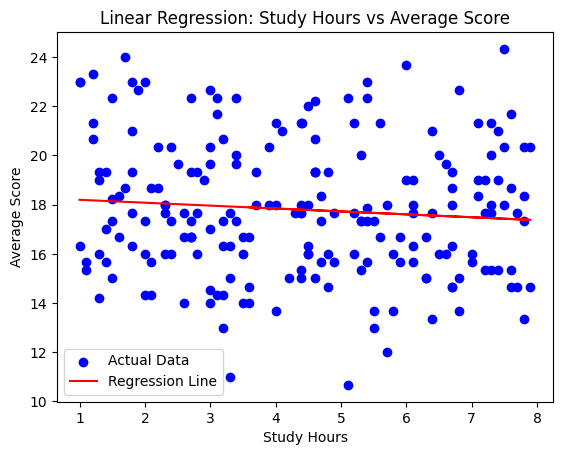

In [15]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Linear Regression: Study Hours vs Average Score")
plt.legend()
plt.show()


In [16]:
new_hours = [[5]]
predicted_score = model.predict(new_hours)
print("\nPredicted Average Score for 5 Study Hours:", predicted_score[0])


Predicted Average Score for 5 Study Hours: 17.723006610470712


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
